In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


In [14]:

# ============================================================================
# CONFIGURATION
# ============================================================================
RESULTS_DIR = "DM_distribution_new"
ALPHA_TO_COMPARE = -4
SAVE_PLOT = True

# List of telescopes to look for
TELESCOPES = [
    "fast", 
    "parkes", 
    "meerkat_coherent", 
    "meerkat_incoherent", 
    "askap_flyeye", 
    "askap_ics"
]

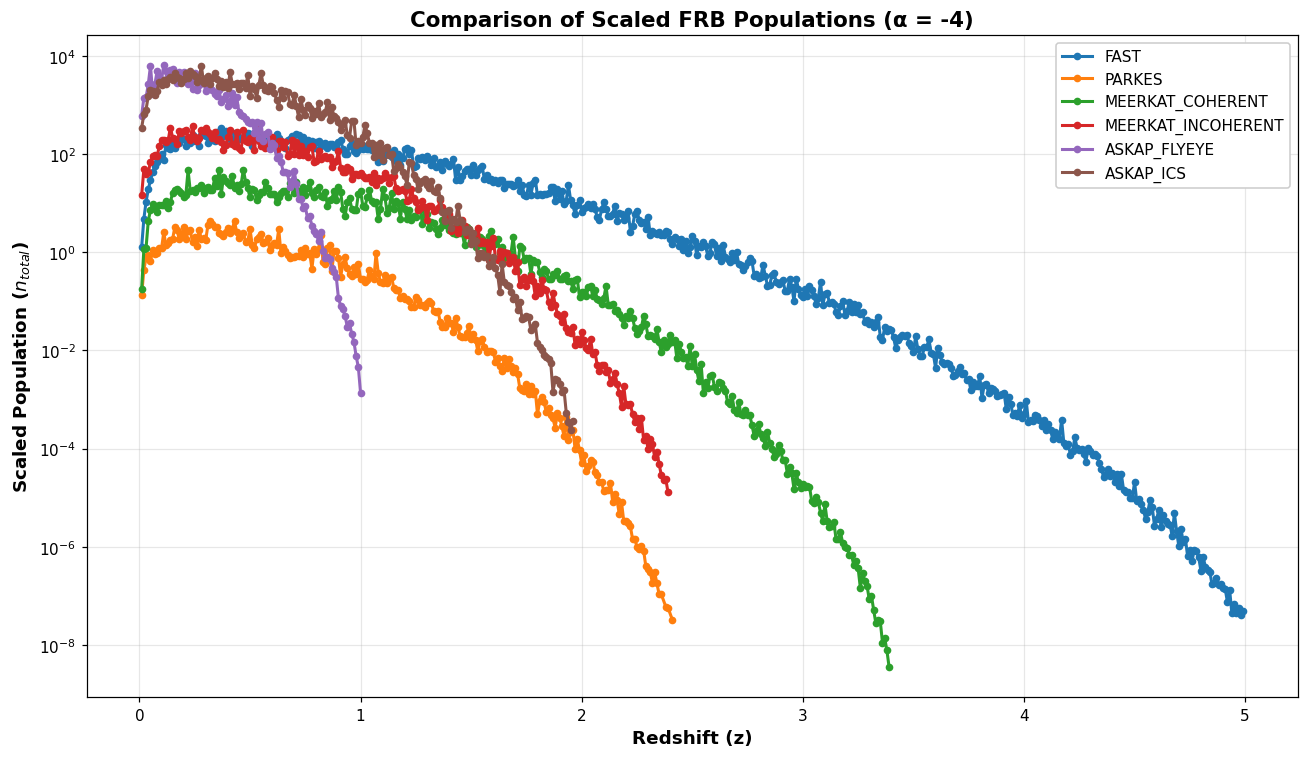


Completed comparison for 6 telescopes.


In [15]:


# ============================================================================
# LOAD AND PLOT
# ============================================================================
plt.figure(figsize=(12, 7), dpi=110)

found_files = 0
for telescope in TELESCOPES:
    # Construct filename based on telescope and alpha
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        
        # Plot Scaled Population vs Redshift
        plt.plot(df['z'], df['n_total_population_scaled'], 
                 marker='o', markersize=4, linewidth=2, label=telescope.upper())
        found_files += 1
    else:
        print(f"File not found: {filename}")

if found_files == 0:
    print(f"No results found for alpha={ALPHA_TO_COMPARE} in {RESULTS_DIR}")
else:
    # Formatting
    plt.title(f'Comparison of Scaled FRB Populations (α = {ALPHA_TO_COMPARE})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Redshift (z)', fontsize=12, fontweight='bold')
    plt.ylabel('Scaled Population ($n_{total}$)', fontsize=12, fontweight='bold')
    
    # Use log scale for Y if the population range is very large
    plt.yscale('log')
    
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(frameon=True, facecolor='white', framealpha=1)
    
    plt.tight_layout()
    
    if SAVE_PLOT:
        plt.savefig(f"population_comparison_alpha{ALPHA_TO_COMPARE}.png")
    
    plt.show()

print(f"\nCompleted comparison for {found_files} telescopes.")